# STAX achieves spot completion while deciphering the complex tumor microenvironment

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

C:\Users\10360\anaconda3\envs\py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import STA as sta

In [4]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [5]:
adata1 = sc.read_h5ad(f'./data/4Completion/align_Visium.h5ad')
adata1.obs_names_make_unique()
adata1.var_names_make_unique()
adata1

AnnData object with n_obs × n_vars = 3955 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cell_type_colors', 'cell_type_sub_colors', 'in_tissue_colors', 'spatial'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw'

In [6]:
adata1.uns['spatial']['CytAssist_FFPE_Human_Breast_Cancer']['scalefactors']['fiducial_diameter_fullres']

191.75371240966362

In [7]:
from STA.pp import compute_global_avg_knn_distance

In [8]:
adata1.obsm['spatial']

array([[ 7411, 15574],
       [12568,  9338],
       [ 9702,  4752],
       ...,
       [13153, 14100],
       [14161, 14569],
       [13308, 10603]])

In [9]:
global_avg, individual_avgs = compute_global_avg_knn_distance(adata1, spatial_key='spatial', k=2)
print("average distance:", global_avg)

average distance: 182.50895332315292


In [10]:
adata_new = sta.pp.make_fake_spot_v2(adata1, spatial_key='spatial', step=90, max_neigh=10)
adata_new

AnnData object with n_obs × n_vars = 18548 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw'

In [11]:
adata_new.obs.loc[:, 'spot_quality'].value_counts()

spot_quality
fake    14593
real     3955
Name: count, dtype: int64

In [12]:
adata_new.obsm['spatial']

array([[ 7411., 15574.],
       [12568.,  9338.],
       [ 9702.,  4752.],
       ...,
       [15135., 16880.],
       [15225., 16880.],
       [15315., 16880.]])

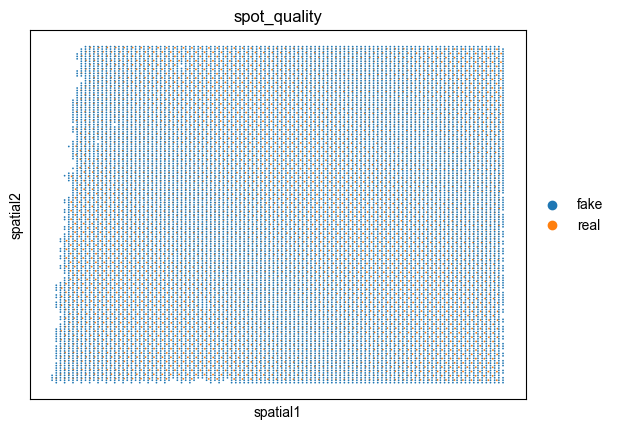

In [13]:
sc.pl.embedding(adata_new, basis='spatial', color=['spot_quality'])

In [14]:
adata_new_real = adata_new[adata_new.obs.loc[:, 'spot_quality'] == 'real', :]
adata_new_real

View of AnnData object with n_obs × n_vars = 3955 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region'
    uns: 'spot_quality_colors'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw'

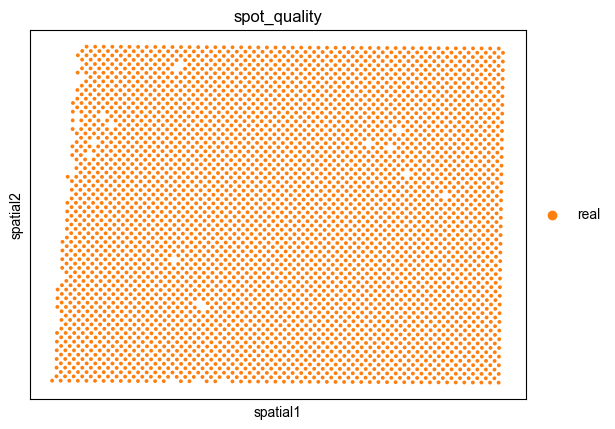

In [15]:
sc.pl.embedding(adata_new_real, basis='spatial', color=['spot_quality'])

In [16]:
adata_new_fake = adata_new[adata_new.obs.loc[:, 'spot_quality'] == 'fake', :]
adata_new_fake

View of AnnData object with n_obs × n_vars = 14593 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region'
    uns: 'spot_quality_colors'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw'

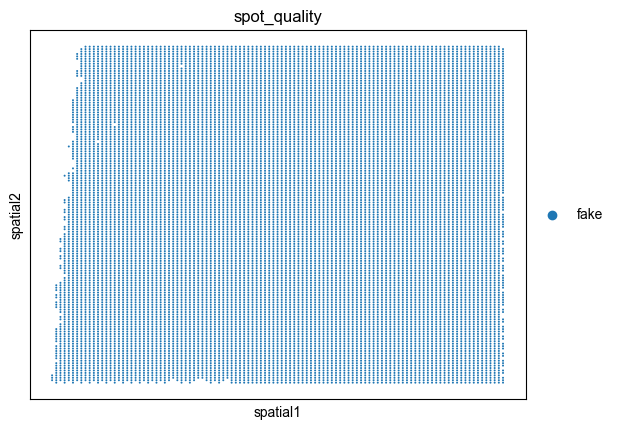

In [17]:
sc.pl.embedding(adata_new_fake, basis='spatial', color=['spot_quality'])

In [18]:
data_list = [adata_new]
batch_key = 'batch'
batch_names = ['adata_new']

adata = sta.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=5000, norm=True, scale='log', target_sum=1e4)
adata

C:\Users\10360\anaconda3\envs\py311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:172: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
C:\Users\10360\anaconda3\envs\py311\Lib\site-packages\scanpy\preprocessing\_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


View of AnnData object with n_obs × n_vars = 18548 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw'
    layers: 'counts', 'norm_log'

In [19]:
adata.uns['spatial'] = adata1.uns['spatial']

C:\Users\10360\AppData\Local\Temp\ipykernel_16896\1805708709.py:1: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['spatial'] = adata1.uns['spatial']


In [20]:
adata.X.max()

7.8573789577359365

In [21]:
rad_cutoff_list = [180]
adata, graph_physical = sta.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list, model='Radius')

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 214138 edges, 18548 cells.
11.5451 neighbors per cell on average.


In [22]:
from scipy.sparse import csr_matrix, vstack
adata.uns['adj'] = graph_physical
adata.uns['adj']

<COOrdinate sparse matrix of dtype 'float64'
	with 232685 stored elements and shape (18548, 18548)>

In [23]:
path_results = f'./log/domain_Visium_newfunction/'

In [24]:
adata_STAX = sta.model.STAX(adata=adata,
                            n_epoch=500,
                            batch_size=len(adata),
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            )

Epochs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:16<00:00,  6.55it/s, recon_loss_mse=447.6568, kl_loss=5.5207, lr: 0.0]


In [25]:
adata_STAX

AnnData object with n_obs × n_vars = 18548 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'spatial', 'adj'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw', 'X_STAX'
    varm: 'gene_embedding'
    layers: 'counts', 'norm_log', 'impute'

In [26]:
adata_STAX.obs

,in_tissue,array_row,array_col,B_Cells,CD4+_T_Cells,CD8+_T_Cells,DCIS_1,DCIS_2,Endothelial,Invasive_Tumor,...,Prolif_Invasive_Tumor,Stromal,Stromal_&_T_Cell_Hybrid,T_Cell_&_Tumor_Hybrid,cell_type,cell_type_sub,spot_quality,Region,original_index,batch
adata_new_0,1,69,87,0.005270,0.000245,0.000033,0.000022,0.000022,0.256977,0.000033,...,0.003766,0.628668,0.000022,0.000022,Stromal,Stromal,real,NaN,0,adata_new
adata_new_1,1,30,30,0.000031,0.005625,0.005625,0.000031,0.000056,0.136610,0.427398,...,0.255589,0.110403,0.022342,0.000031,Invasive_Tumor,Invasive_Tumor,real,NaN,1,adata_new
adata_new_2,1,1,61,0.000044,0.000066,0.000066,0.000044,0.000117,0.098772,0.634117,...,0.018698,0.164091,0.000044,0.000044,Invasive_Tumor,Invasive_Tumor,real,NaN,2,adata_new
adata_new_3,1,5,23,0.001411,0.091492,0.084979,0.000045,0.000045,0.056132,0.102172,...,0.175396,0.287135,0.217445,0.000045,Stromal,Stromal,real,NaN,3,adata_new
adata_new_4,1,11,91,0.000015,0.000023,0.000023,0.000015,0.000029,0.043539,0.560356,...,0.312030,0.066593,0.000015,0.000015,Invasive_Tumor,Invasive_Tumor,real,NaN,4,adata_new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
adata_new_18543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fake,fake,18543,adata_new
adata_new_18544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fake,fake,18544,adata_new
adata_new_18545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fake,fake,18545,adata_new
adata_new_18546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fake,fake,18546,adata_new


In [27]:
sc.pp.neighbors(adata_STAX, use_rep='X_STAX')

In [28]:
sc.tl.umap(adata_STAX)

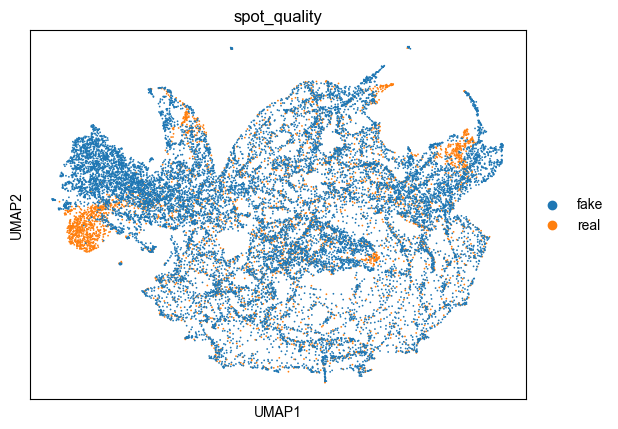

In [29]:
sc.pl.umap(adata_STAX, color=['spot_quality'])

In [30]:
adata_STAX_real = adata_STAX[adata_STAX.obs.loc[:, 'spot_quality'] == 'real', :]
adata_STAX_real

View of AnnData object with n_obs × n_vars = 3955 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'spatial', 'adj', 'neighbors', 'umap', 'spot_quality_colors'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw', 'X_STAX', 'X_umap'
    varm: 'gene_embedding'
    layers: 'counts', 'norm_log', 'impute'
    obsp: 'distances', 'connectivities'

In [31]:
adata_STAX_fake = adata_STAX[adata_STAX.obs.loc[:, 'spot_quality'] == 'fake', :]
adata_STAX_fake

View of AnnData object with n_obs × n_vars = 14593 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'spatial', 'adj', 'neighbors', 'umap', 'spot_quality_colors'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw', 'X_STAX', 'X_umap'
    varm: 'gene_embedding'
    layers: 'counts', 'norm_log', 'impute'
    obsp: 'distances', 'connectivities'

# result

In [32]:
sc.pp.neighbors(adata_STAX_fake, use_rep='X_STAX')

In [33]:
sc.tl.umap(adata_STAX_fake)

In [34]:
sc.tl.louvain(adata_STAX_fake, resolution=0.2)

In [35]:
sc.tl.leiden(adata_STAX_fake, resolution=0.1)

C:\Users\10360\AppData\Local\Temp\ipykernel_16896\2991876637.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_STAX_fake, resolution=0.1)


In [36]:
sta.tl.kmeans_cluster(adata_STAX_fake, mode='KMeans', used_embedding='X_STAX', n_clusters=10)

E:\学习\6科研\论文\博士论文\STAX\code\STA\tools\clustering.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0' '0' '0' ... '0' '0' '0']' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  adata.obs.loc[:, 'kmeans'] = adata.obs.loc[:, 'kmeans'].astype(str)


AnnData object with n_obs × n_vars = 14593 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch', 'louvain', 'leiden', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'spatial', 'adj', 'neighbors', 'umap', 'spot_quality_colors', 'louvain', 'leiden'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw', 'X_STAX', 'X_umap'
    varm: 'gene_embedding'
    layers: 'counts', 'norm_log', 'impute'
    obsp: 'distances', 'connectivities'

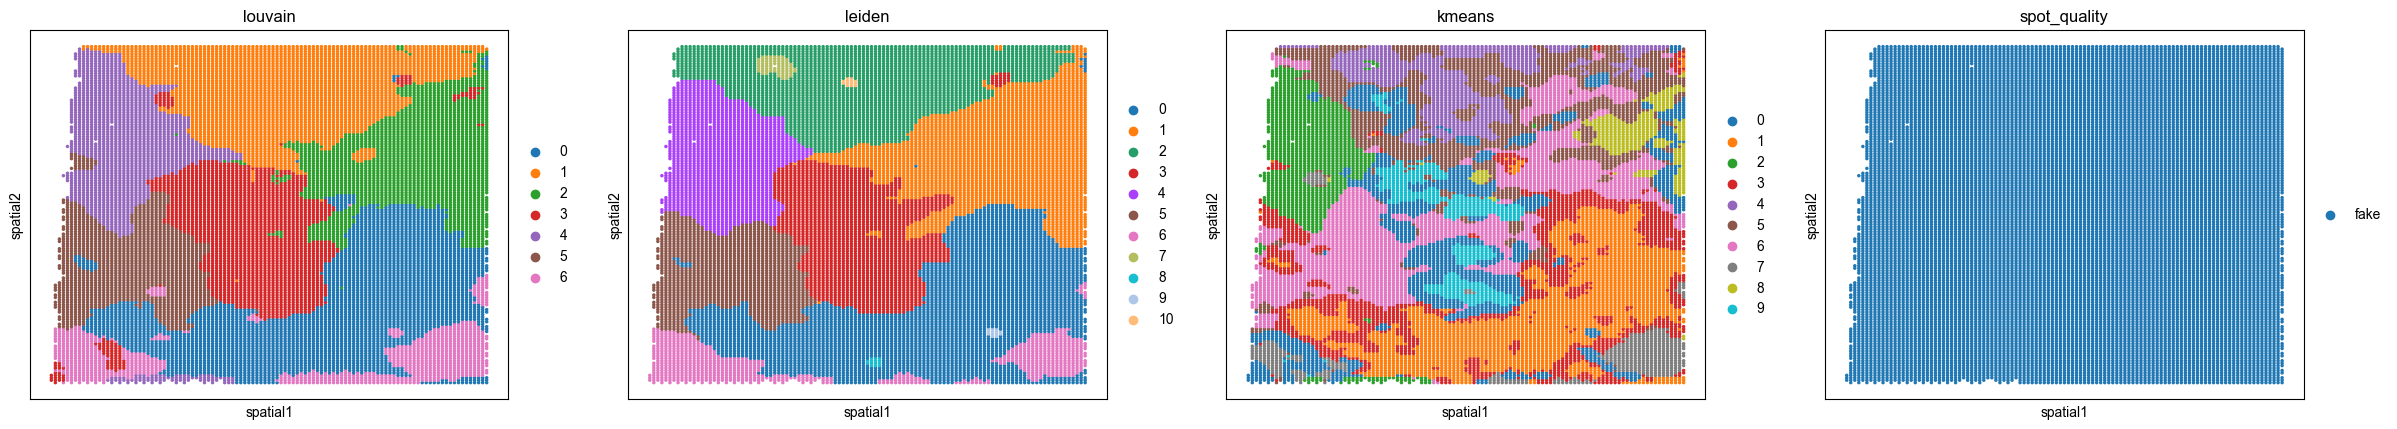

In [37]:
# fake 10
sc.pl.embedding(adata_STAX_fake, color=['louvain', 'leiden', 'kmeans', 'spot_quality'], basis='spatial', size=25)

# impute

In [38]:
adata_STAX_impute = adata_STAX_fake.copy()
adata_STAX_impute.X = adata_STAX_impute.layers['impute']
adata_STAX_impute.raw = adata_STAX_impute
adata_STAX_impute

AnnData object with n_obs × n_vars = 14593 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2', 'Endothelial', 'Invasive_Tumor', 'IRF7+_DCs', 'LAMP3+_DCs', 'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+', 'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor', 'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'cell_type', 'cell_type_sub', 'spot_quality', 'Region', 'original_index', 'batch', 'louvain', 'leiden', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'spatial', 'adj', 'neighbors', 'umap', 'spot_quality_colors', 'louvain', 'leiden', 'louvain_colors', 'leiden_colors', 'kmeans_colors'
    obsm: 'X_pca', 'align_spatial', 'align_spatial_nonrigid', 'align_spatial_rigid', 'spatial', 'spatial_raw', 'X_STAX', 'X_umap'
    varm: 'gene_embedding'
    layers: 'counts', 'norm_log', 'impute'
    

In [39]:
del adata_STAX_impute.uns['adj']

In [40]:
adata_STAX_impute.X.max(), adata_STAX_impute.X.min()

(7.95839262008667, 0.0)

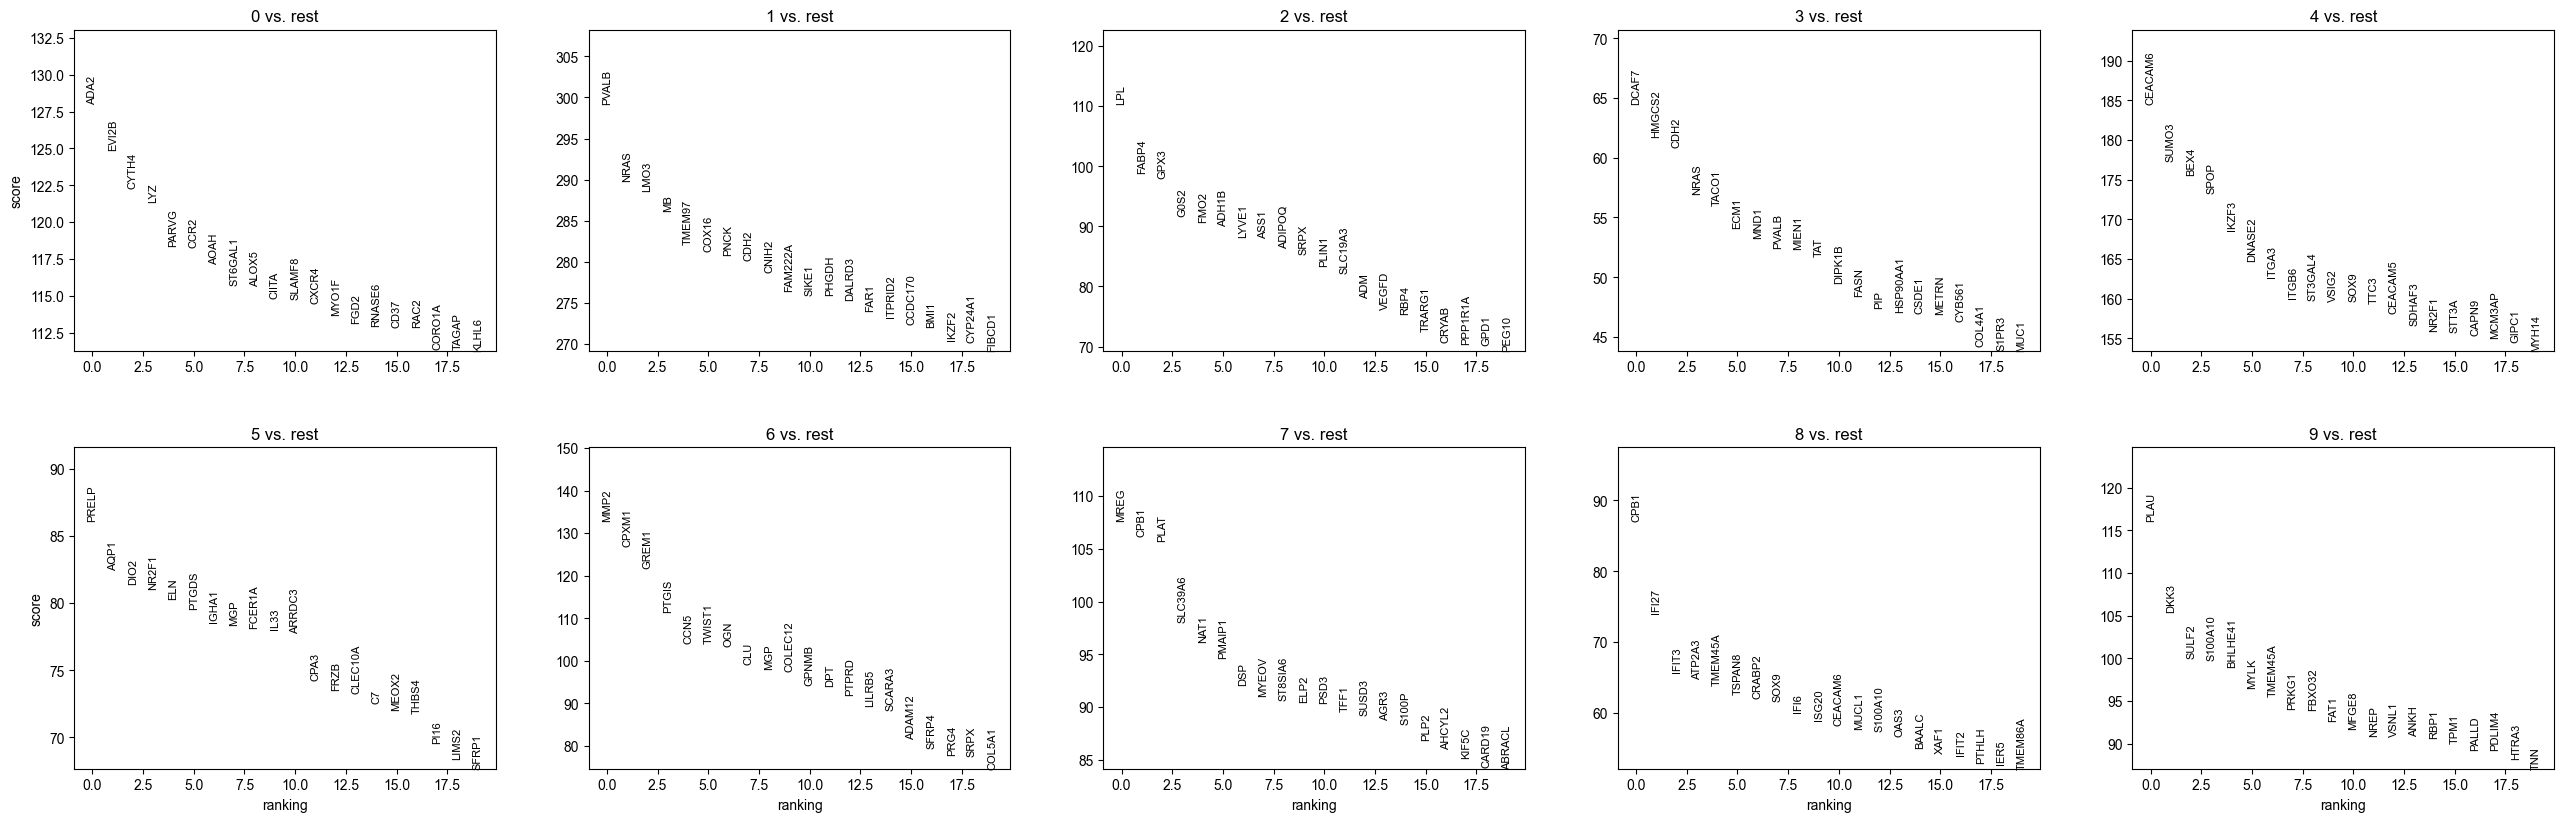

In [41]:
sc.tl.rank_genes_groups(adata_STAX_impute, "kmeans", method="t-test")
sc.pl.rank_genes_groups(adata_STAX_impute, n_genes=20, sharey=False, ncols=5)

In [42]:
result = adata_STAX_impute.uns["rank_genes_groups"]
groups = result["names"].dtype.names
degs = pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names"]
    }
).head(18)
degs

,0_n,1_n,2_n,3_n,4_n,5_n,6_n,7_n,8_n,9_n
0,ADA2,PVALB,LPL,DCAF7,CEACAM6,PRELP,MMP2,MREG,CPB1,PLAU
1,EVI2B,NRAS,FABP4,HMGCS2,SUMO3,AQP1,CPXM1,CPB1,IFI27,DKK3
2,CYTH4,LMO3,GPX3,CDH2,BEX4,DIO2,GREM1,PLAT,IFIT3,SULF2
3,LYZ,MB,G0S2,NRAS,SPOP,NR2F1,PTGIS,SLC39A6,ATP2A3,S100A10
4,PARVG,TMEM97,FMO2,TACO1,IKZF3,ELN,CCN5,NAT1,TMEM45A,BHLHE41
5,CCR2,COX16,ADH1B,ECM1,DNASE2,PTGDS,TWIST1,PMAIP1,TSPAN8,MYLK
6,AOAH,PNCK,LYVE1,MND1,ITGA3,IGHA1,OGN,DSP,CRABP2,TMEM45A
7,ST6GAL1,CDH2,ASS1,PVALB,ITGB6,MGP,CLU,MYEOV,SOX9,PRKG1
8,ALOX5,CNIH2,ADIPOQ,MIEN1,ST3GAL4,FCER1A,MGP,ST8SIA6,IFI6,FBXO32
9,CIITA,FAM222A,SRPX,TAT,VSIG2,IL33,COLEC12,ELP2,ISG20,FAT1


0_n


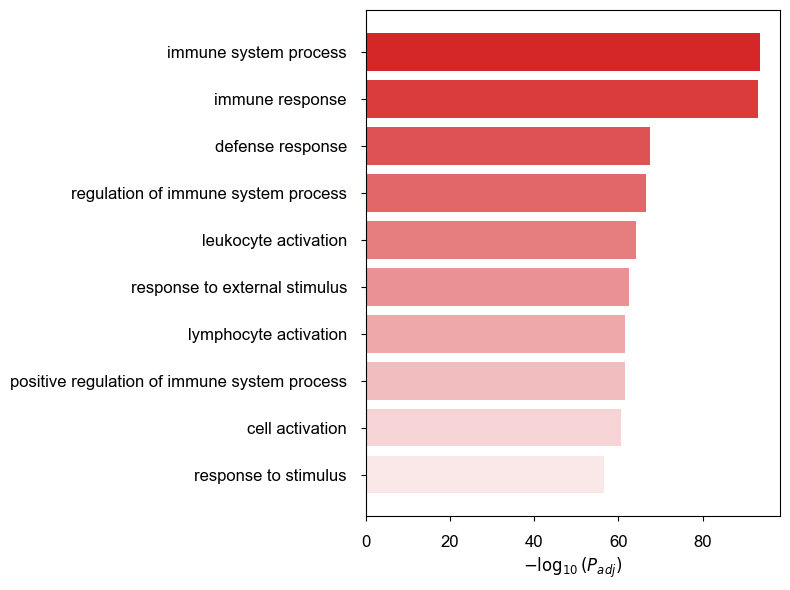

3_n


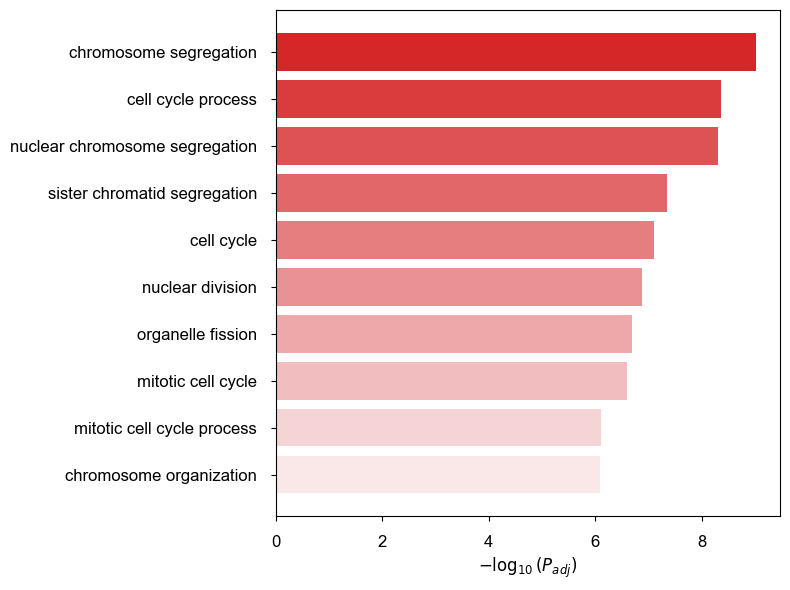

5_n


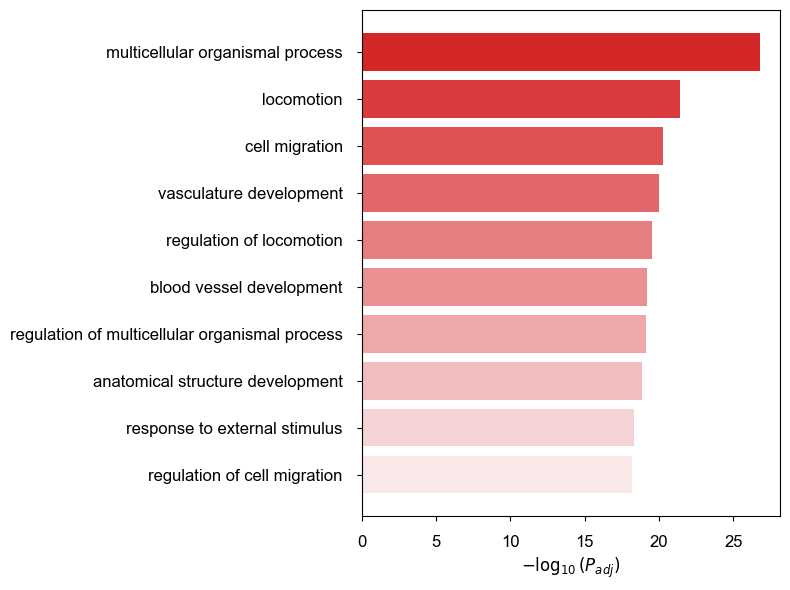

In [44]:
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import matplotlib.colors
for i, item in enumerate(degs.columns):
    if i not in [0, 3, 5]:
        continue
    print(item)
    gp = GProfiler(return_dataframe=True)
    deg = list(sc.get.rank_genes_groups_df(adata_STAX_impute, group=item[0: -2], key='rank_genes_groups', pval_cutoff=0.05, log2fc_min=0.5)['names'])
    results = gp.profile(query=deg, 
                     organism='hsapiens',  # 
                     # all_results=True,
                    )
    results.to_csv(f'GO_{i}.csv', index=True, header=True)
    results = results.loc[:, ['p_value', 'name', 'source', 'recall']]  # 
    results.sort_values(by='p_value', ascending=True, inplace=True)  # 
    GO_results = results.loc[results.loc[:, 'source'].str.startswith('GO:BP'), :]
    if len(GO_results) >=10:
        results = GO_results
    results.index = range(len(results))
    go_colors = ["#FFEBEDFF", "#FFCCD2FF", "#EE9999FF", "#E57272FF", "#EE5250FF",
                 "#F34335FF", "#E53934FF", "#D22E2EFF", "#C52727FF", "#B71B1BFF"][::-1]
    
    alphas = np.linspace(0.1, 1, 10)
    rgba_colors = np.zeros((10, 4))
    # for red the first column needs to be one
    rgba_colors[:, :3] = matplotlib.colors.hex2color("tab:red")
    # the fourth column needs to be your alphas
    rgba_colors[:, 3] = alphas
    go_colors = rgba_colors[::-1]
    
    plt.figure(figsize=(8, 6))
    
    for i in range(10):
        plt.barh(10 - i, -np.log10(results.loc[i]['p_value']), color=go_colors[i])
    fontsize = 12
    plt.xticks(fontsize=fontsize)
    plt.yticks(10 - np.arange(10), [go for go in results['name'][:10].values], fontsize=fontsize)
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', pad=10)
    ax.xaxis.set_ticks_position('bottom')
    ax.grid(False)
    plt.xlabel("$-\log_{10}(P_{adj})$", fontsize=fontsize)
    plt.tight_layout()
    # plt.savefig(f'./fig_visium100/GO_visium100_kmeans_{item}')
    plt.show()
    # break